In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import PolynomialFeatures


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Program Files\Anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Program Files\Anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Program Files\Anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Program Files\Anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Program Files\Anaconda3\lib

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Program Files\Anaconda3\lib\runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Program Files\Anaconda3\lib\runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "c:\Program Files\Anaconda3\lib\site-packages\ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "c:\Program Files\Anaconda3\lib\site-packages\traitlets\config\application.py", line 846, in launch_instance
    app.start()
  File "c:\Program Files\Anaconda3\lib

AttributeError: _ARRAY_API not found

In [2]:
dataset = pd.read_csv(r"C:\Ddrive\Bits\sem1\ML\Assignment2\diabetes_binary_health_indicators_BRFSS2015.csv")
X = dataset.drop('Diabetes_binary', axis=1)
y = dataset['Diabetes_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [3]:
Xy_test = X_test.copy()
Xy_test['Diabetes_binary'] = y_test
Xy_test.to_csv(r"C:\Ddrive\Bits\sem1\ML\Assignment2\Xy_test.csv", index=True)

In [4]:
Binary_cols = [col for col in dataset.columns if set(dataset[col].dropna().unique()).issubset({0.0, 1.0})]
print(Binary_cols)
print(len(Binary_cols))
non_binary_cols = [col for col in dataset.columns if col not in Binary_cols]
print(non_binary_cols)
print(len(non_binary_cols))

['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
15
['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
7


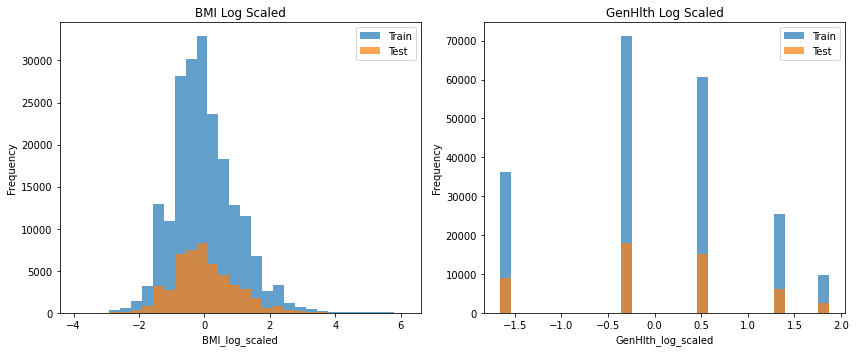

In [5]:
X_train['BMI_log'] = np.log1p(X_train['BMI'])
X_test['BMI_log'] = np.log1p(X_test['BMI'])
X_train['GenHlth_log'] = np.log1p(X_train['GenHlth'])
X_test['GenHlth_log'] = np.log1p(X_test['GenHlth'])
scaler = StandardScaler()
X_train['BMI_log_scaled'] = scaler.fit_transform(X_train[['BMI_log']])
X_test['BMI_log_scaled'] = scaler.transform(X_test[['BMI_log']])
X_train['GenHlth_log_scaled'] = scaler.fit_transform(X_train[['GenHlth_log']])
X_test['GenHlth_log_scaled'] = scaler.transform(X_test[['GenHlth_log']])
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot BMI_log_scaled
axs[0].hist(X_train['BMI_log_scaled'], bins=30, alpha=0.7, label='Train')
axs[0].hist(X_test['BMI_log_scaled'], bins=30, alpha=0.7, label='Test')
axs[0].set_title('BMI Log Scaled')
axs[0].set_xlabel('BMI_log_scaled')
axs[0].set_ylabel('Frequency')
axs[0].legend()

# Plot GenHlth_log_scaled
axs[1].hist(X_train['GenHlth_log_scaled'], bins=30, alpha=0.7, label='Train')
axs[1].hist(X_test['GenHlth_log_scaled'], bins=30, alpha=0.7, label='Test')
axs[1].set_title('GenHlth Log Scaled')
axs[1].set_xlabel('GenHlth_log_scaled')
axs[1].set_ylabel('Frequency')
axs[1].legend()

plt.tight_layout()
plt.show()

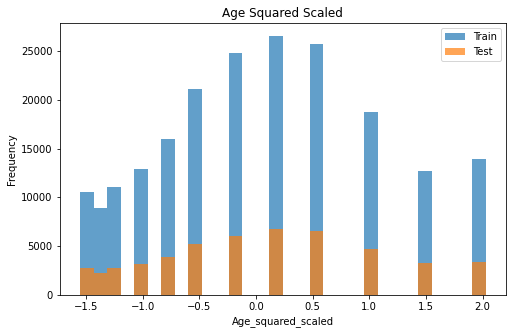

In [6]:
# Apply square transform to Age
X_train['Age_squared'] = X_train['Age'] ** 2
X_test['Age_squared'] = X_test['Age'] ** 2

# Standard scaling for Age_squared
scaler_age_sq = StandardScaler()
X_train['Age_squared_scaled'] = scaler_age_sq.fit_transform(X_train[['Age_squared']])
X_test['Age_squared_scaled'] = scaler_age_sq.transform(X_test[['Age_squared']])
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(X_train['Age_squared_scaled'], bins=30, alpha=0.7, label='Train')
ax.hist(X_test['Age_squared_scaled'], bins=30, alpha=0.7, label='Test')
ax.set_title('Age Squared Scaled')
ax.set_xlabel('Age_squared_scaled')
ax.set_ylabel('Frequency')
ax.legend()
plt.show()

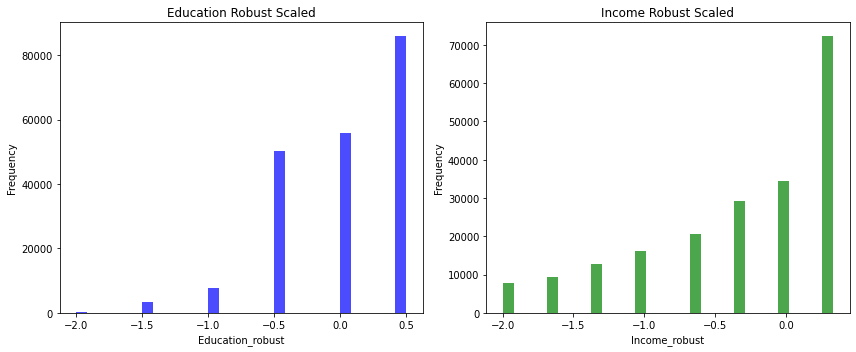

In [7]:
scaler_robust = RobustScaler()
X_train[['Education_robust', 'Income_robust']] = scaler_robust.fit_transform(X_train[['Education', 'Income']])
X_test[['Education_robust', 'Income_robust']] = scaler_robust.transform(X_test[['Education', 'Income']])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot Education_robust
axs[0].hist(X_train['Education_robust'], bins=30, alpha=0.7, color='blue')
axs[0].set_title('Education Robust Scaled')
axs[0].set_xlabel('Education_robust')
axs[0].set_ylabel('Frequency')

# Plot Income_robust
axs[1].hist(X_train['Income_robust'], bins=30, alpha=0.7, color='green')
axs[1].set_title('Income Robust Scaled')
axs[1].set_xlabel('Income_robust')
axs[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

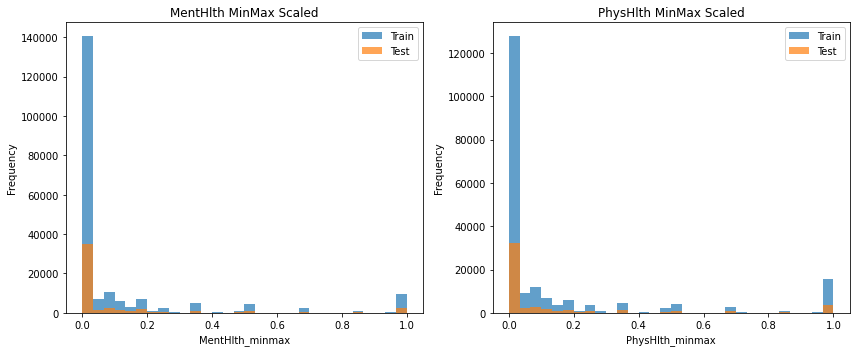

In [8]:
# Apply MinMaxScaler to MentHlth and PhysHlth
minmax_scaler = MinMaxScaler()
X_train[['MentHlth_minmax', 'PhysHlth_minmax']] = minmax_scaler.fit_transform(X_train[['MentHlth', 'PhysHlth']])
X_test[['MentHlth_minmax', 'PhysHlth_minmax']] = minmax_scaler.transform(X_test[['MentHlth', 'PhysHlth']])

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot MentHlth_minmax
axs[0].hist(X_train['MentHlth_minmax'], bins=30, alpha=0.7, label='Train')
axs[0].hist(X_test['MentHlth_minmax'], bins=30, alpha=0.7, label='Test')
axs[0].set_title('MentHlth MinMax Scaled')
axs[0].set_xlabel('MentHlth_minmax')
axs[0].set_ylabel('Frequency')
axs[0].legend()

# Plot PhysHlth_minmax
axs[1].hist(X_train['PhysHlth_minmax'], bins=30, alpha=0.7, label='Train')
axs[1].hist(X_test['PhysHlth_minmax'], bins=30, alpha=0.7, label='Test')
axs[1].set_title('PhysHlth MinMax Scaled')
axs[1].set_xlabel('PhysHlth_minmax')
axs[1].set_ylabel('Frequency')
axs[1].legend()

plt.tight_layout()
plt.show()

In [9]:
print(X_train.columns.tolist())
Trainlist = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'BMI_log_scaled', 'GenHlth_log_scaled', 'Age_squared_scaled', 'Education_robust', 'Income_robust', 'MentHlth_minmax', 'PhysHlth_minmax']
Trainlist_logreg = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'BMI_log_scaled', 'GenHlth_log_scaled', 'Age_squared_scaled', 'Education_robust', 'Income_robust', 'MentHlth_minmax', 'PhysHlth_minmax']

['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'BMI_log', 'GenHlth_log', 'BMI_log_scaled', 'GenHlth_log_scaled', 'Age_squared', 'Age_squared_scaled', 'Education_robust', 'Income_robust', 'MentHlth_minmax', 'PhysHlth_minmax']


In [10]:
binary_cols_trainlist = [col for col in Trainlist if set(X_train[col].dropna().unique()).issubset({0.0, 1.0})]
non_binary_cols_trainlist = [col for col in Trainlist if col not in binary_cols_trainlist]
print("Binary columns in Trainlist:", binary_cols_trainlist)
print("Non-binary columns in Trainlist:", non_binary_cols_trainlist)

Binary columns in Trainlist: ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex']
Non-binary columns in Trainlist: ['BMI_log_scaled', 'GenHlth_log_scaled', 'Age_squared_scaled', 'Education_robust', 'Income_robust', 'MentHlth_minmax', 'PhysHlth_minmax']


In [11]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train[non_binary_cols_trainlist])
X_test_poly = poly.transform(X_test[non_binary_cols_trainlist])

# Get feature names for the expanded columns
poly_feature_names = poly.get_feature_names_out(non_binary_cols_trainlist)

# Convert to DataFrame for easier handling
X_train_poly_df = pd.DataFrame(X_train_poly, columns=poly_feature_names, index=X_train.index)
X_test_poly_df = pd.DataFrame(X_test_poly, columns=poly_feature_names, index=X_test.index)

# Concatenate the polynomial features with the original columns (excluding those already in poly features to avoid duplication)
other_cols_train = X_train.drop(columns=non_binary_cols_trainlist)
other_cols_test = X_test.drop(columns=non_binary_cols_trainlist)

X_train_poly_df = pd.concat([other_cols_train, X_train_poly_df], axis=1)
X_test_poly_df = pd.concat([other_cols_test, X_test_poly_df], axis=1)

In [12]:
Trainlist_logreg = Trainlist_logreg + list(poly_feature_names)
Trainlist_logreg = list(dict.fromkeys(Trainlist_logreg))
print(Trainlist_logreg)

['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'Sex', 'BMI_log_scaled', 'GenHlth_log_scaled', 'Age_squared_scaled', 'Education_robust', 'Income_robust', 'MentHlth_minmax', 'PhysHlth_minmax', 'BMI_log_scaled^2', 'BMI_log_scaled GenHlth_log_scaled', 'BMI_log_scaled Age_squared_scaled', 'BMI_log_scaled Education_robust', 'BMI_log_scaled Income_robust', 'BMI_log_scaled MentHlth_minmax', 'BMI_log_scaled PhysHlth_minmax', 'GenHlth_log_scaled^2', 'GenHlth_log_scaled Age_squared_scaled', 'GenHlth_log_scaled Education_robust', 'GenHlth_log_scaled Income_robust', 'GenHlth_log_scaled MentHlth_minmax', 'GenHlth_log_scaled PhysHlth_minmax', 'Age_squared_scaled^2', 'Age_squared_scaled Education_robust', 'Age_squared_scaled Income_robust', 'Age_squared_scaled MentHlth_minmax', 'Age_squared_scaled PhysHlth_minmax', 'Education_robust^2', 'Education_robust Income_robust'

In [13]:
logreg = LogisticRegression(
    C=0.01,
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
logreg.fit(X_train_poly_df[Trainlist_logreg], y_train)

LogisticRegression(C=0.01, class_weight='balanced', l1_ratio=0.5, max_iter=2000,
                   penalty='elasticnet', random_state=42, solver='saga')

In [14]:
dtree = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    ccp_alpha=0.0,
    criterion='gini',
    max_depth=7,
    min_samples_leaf=10,
    min_samples_split=2
)
dtree.fit(X_train[Trainlist], y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=7,
                       min_samples_leaf=10, random_state=42)

In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=1,
    class_weight='balanced_subsample',
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train[Trainlist], y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=8,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [16]:
knn = KNeighborsClassifier(n_neighbors=3, p=2, weights='distance', n_jobs=-1)
knn.fit(X_train[Trainlist], y_train)

KNeighborsClassifier(n_jobs=-1, n_neighbors=3, weights='distance')

In [17]:
sample_weights_gnb = compute_sample_weight(class_weight='balanced', y=y_train)
gnb = GaussianNB()
gnb.fit(X_train[Trainlist], y_train, sample_weight=sample_weights_gnb)

GaussianNB()

In [18]:
xgb_best = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    colsample_bytree=0.8,
    learning_rate=0.2,
    max_depth=3,
    n_estimators=200,
    scale_pos_weight=5,
    subsample=0.8
)
xgb_best.fit(X_train[Trainlist], y_train)

C:\Users\pdt1cob\AppData\Roaming\Python\Python39\site-packages\xgboost\core.py:158: UserWarning: [16:05:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [19]:
def evaluate_model(name, model, X, y_true, y_pred):
    return [
        name,
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='binary'),
        recall_score(y_true, y_pred, average='binary'),
        f1_score(y_true, y_pred, average='binary'),
        roc_auc_score(y_true, model.predict_proba(X)[:, 1]),
        matthews_corrcoef(y_true, y_pred)
    ]

In [20]:
y_pred_logreg = logreg.predict(X_test_poly_df[Trainlist_logreg])
y_pred_dtree = dtree.predict(X_test[Trainlist])
y_pred_rf = rf.predict(X_test[Trainlist])
y_pred_knn = knn.predict(X_test[Trainlist])
y_pred_gnb = gnb.predict(X_test[Trainlist])
y_pred_xgb = xgb_best.predict(X_test[Trainlist])

In [21]:
results = []
results.append(evaluate_model("Logistic Regression", logreg, X_test_poly_df[Trainlist_logreg], y_test, y_pred_logreg))
results.append(evaluate_model("Decision Tree", dtree, X_test[Trainlist], y_test, y_pred_dtree))
results.append(evaluate_model("KNN", knn, X_test[Trainlist], y_test, y_pred_knn))
results.append(evaluate_model("GaussianNB", gnb, X_test[Trainlist], y_test, y_pred_gnb))
results.append(evaluate_model("Random Forest", rf, X_test[Trainlist], y_test, y_pred_rf))
results.append(evaluate_model("Xgboost", xgb_best, X_test[Trainlist], y_test, y_pred_xgb))

metrics = ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "AUC", "Matthews Corrcoef"]
results_df = pd.DataFrame(results, columns=metrics)
print(results_df.round(4))

                 Model  Accuracy  Precision  Recall  F1 Score     AUC  \
0  Logistic Regression    0.7227     0.3066  0.7848    0.4409  0.8239   
1        Decision Tree    0.7113     0.2951  0.7721    0.4270  0.8119   
2                  KNN    0.8338     0.3633  0.2562    0.3005  0.6866   
3           GaussianNB    0.7209     0.2933  0.7116    0.4154  0.7801   
4        Random Forest    0.7226     0.3048  0.7737    0.4373  0.8203   
5              Xgboost    0.7528     0.3287  0.7430    0.4557  0.8270   

   Matthews Corrcoef  
0             0.3596  
1             0.3407  
2             0.2135  
3             0.3177  
4             0.3535  
5             0.3708  


In [22]:
joblib.dump(logreg, r"C:\Ddrive\Bits\sem1\ML\Assignment2\ML-Classification-models-and-eval-metrics\models\Logistic_Regression_model.pkl")
joblib.dump(dtree, r"C:\Ddrive\Bits\sem1\ML\Assignment2\ML-Classification-models-and-eval-metrics\models\Decision_Tree_model.pkl")
joblib.dump(knn, r"C:\Ddrive\Bits\sem1\ML\Assignment2\ML-Classification-models-and-eval-metrics\models\K_nearest_Neighbour_model.pkl")
joblib.dump(gnb, r"C:\Ddrive\Bits\sem1\ML\Assignment2\ML-Classification-models-and-eval-metrics\models\Gaussian_Naive_Bayes_model.pkl")
joblib.dump(rf, r"C:\Ddrive\Bits\sem1\ML\Assignment2\ML-Classification-models-and-eval-metrics\models\Random_Forest_model.pkl")
joblib.dump(xgb_best, r"C:\Ddrive\Bits\sem1\ML\Assignment2\ML-Classification-models-and-eval-metrics\models\XgBoost_model.pkl")

['C:\\Ddrive\\Bits\\sem1\\ML\\Assignment2\\ML-Classification-models-and-eval-metrics\\models\\XgBoost_model.pkl']